### Using randomly generated  (stroke onset during sleep) to predict the next dependant variable (precise onset of stroke known)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random as rn
import seaborn as sns 
import csv

In [16]:
num_samples=1000

In [17]:
df_n=pd.read_csv("combo_sleep_precise.csv", index_col="precise_onset_known")

In [18]:
df_n

,0,1
precise_onset_known,,
0,0.33568,0.04340
1,0.62091,0.00001


In [19]:
u=df_n.loc[0,"0"]#0.33568
v=df_n.loc[0,"1"]
w=df_n.loc[1,"0"]
x=df_n.loc[1,"1"]
#no quote marks for rows

u1=u/(u+w)
w1=w/(u+w)

v1=v/(v+x)
x1=x/(v+x)

In [33]:
num_rows = 1000
# Pick feature 1 at random:
p = v+x
np.random.seed(42)
f1 = np.random.binomial(1, p, num_rows)

# Start with all feature 2 as zero:
#f2 = np.zeros(num_rows)
f2=np.full(num_rows,42)

# Update feature 2 depending on feature 1.
# Pick out where feature 1 is zero:
inds_f1_0 = np.where(f1 == 0)

# How many times is feature 1 zero?
num_f1_0 = len(inds_f1_0[0])

inds_f1_1= np.where(f1==1)
num_f1_1= len(inds_f1_1[0])

# Generate new vals for feature 2 when feature 1 is zero:
f2_vals = np.random.choice([0, 1], num_f1_0, p=[u1,w1])
# Update feature 2 with the new values:
f2[inds_f1_0] = f2_vals

f1_vals=np.random.choice([0, 1], num_f1_1, p=[v1,x1])
f2[inds_f1_1]=f1_vals

In [34]:
f1_vals

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [35]:
f2_vals

array([0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,

In [36]:
df_b=pd.Series(f1)
df_c=pd.Series(f2)

In [37]:
df_d=pd.concat([df_b,df_c], axis=1)
df_d.columns=["Onset_during_sleep","Precise_onset_known"]

In [38]:
df_d

,Onset_during_sleep,Precise_onset_known
0,0,0
1,0,1
2,0,1
3,0,1
4,0,1
...,...,...
995,0,1
996,0,1
997,0,1
998,0,0


In [39]:
df_d.value_counts()

Onset_during_sleep  Precise_onset_known
0                   1                      634
                    0                      328
1                   0                       38
Name: count, dtype: int64

In [40]:
def grid_overlap_two(df, col1, col2):
    """
    Convert two df column counts into a grid.

    df should contain two columns called col1 and col2.
    This finds how many rows of data have each combined values
    of col1 and col2.
    """
    # How many people are in each combo of values?
    df_g = df[[col1, col2]].value_counts()
    df_g.name = 'counts'

    # # Convert counts to proportion of all patients:
    # df_g = df_g / df_g.sum()

    # Convert list to grid:
    df_g = df_g.reset_index()
    df_g = df_g.pivot(columns=col1, index=col2, values='counts')
    return df_g

In [41]:
df_g=grid_overlap_two(df_d,"Onset_during_sleep","Precise_onset_known")

In [44]:
df_g

Onset_during_sleep,0,1
Precise_onset_known,,
0,328.0,38.0
1,634.0,NaN


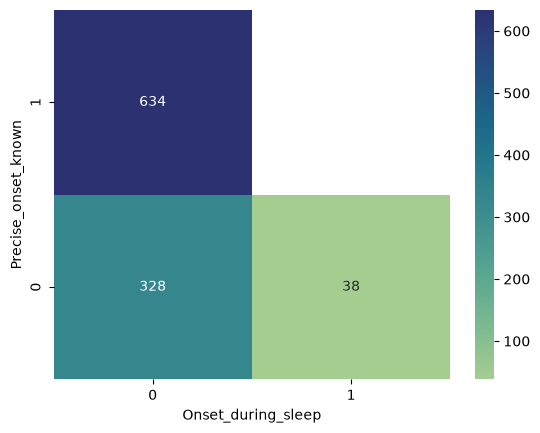

In [45]:
ax=sns.heatmap(df_g, cmap="crest", annot=True,fmt="g")#format- general (not scientific)
ax.invert_yaxis()